In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys, math, json, random, warnings
from pathlib import Path
from sklearn.utils import resample
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report, average_precision_score, r2_score, mean_squared_error

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

print("Versions: numpy", np.__version__, "| pandas", pd.__version__)

Versions: numpy 2.3.3 | pandas 2.3.2


In [31]:
DATA_2014 = Path('/Users/mlwu/Documents/Academia/CMU/tepper_courses/Business Value Through Integrative Analytics/cases/case_2/data/LoanStats3c.csv')  # 2014 archive
DATA_2015 = Path('/Users/mlwu/Documents/Academia/CMU/tepper_courses/Business Value Through Integrative Analytics/cases/case_2/data/LoanStats3d.csv')  # 2015 archive
DICT_XLSX = Path('/mnt/data/LCDataDictionary.xlsx')

assert DATA_2014.exists(), f"Missing file: {DATA_2014}"
assert DATA_2015.exists(), f"Missing file: {DATA_2015}"

def load_lc_csv(path: Path) -> pd.DataFrame:
     # Skip the first row (disclaimer), Pandas will use the second row as header
    df = pd.read_csv(path, skiprows=1, low_memory=False)

    # Drop completely empty rows/cols
    df = df.dropna(how='all', axis=0).dropna(how='all', axis=1)

    # Normalize column names
    df.columns = (
        df.columns
          .str.strip()
          .str.lower()
          .str.replace(" ", "_")
    )

    # Remove footer disclaimer rows if still present
    if "loan_status" in df.columns:
        df = df[df["loan_status"].notna()]

    return df.reset_index(drop=True)

df14 = load_lc_csv("/Users/mlwu/Documents/Academia/CMU/tepper_courses/Business Value Through Integrative Analytics/cases/case_2/data/LoanStats3c.csv")
df15 = load_lc_csv("/Users/mlwu/Documents/Academia/CMU/tepper_courses/Business Value Through Integrative Analytics/cases/case_2/data/LoanStats3d.csv")

print("2014 shape:", df14.shape)
print("2015 shape:", df15.shape)
print("First few columns 2014:", df14.columns[:10])
print("First few columns 2015:", df15.columns[:10])

def label_default(s: str):
    s = str(s).lower()
    if "charged off" in s or "default" in s:
        return 1
    if "fully paid" in s:
        return 0
    return np.nan

df = pd.concat([df14, df15], ignore_index=True)
df["y_default"] = df["loan_status"].map(label_default)

mod = df[df["y_default"].notna()].copy()
print("Post-filter shape:", mod.shape, "| Default rate:", mod["y_default"].mean().round(3))

2014 shape: (235629, 113)
2015 shape: (421095, 130)
First few columns 2014: Index(['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title'], dtype='object')
First few columns 2015: Index(['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title'], dtype='object')
Post-filter shape: (656724, 131) | Default rate: 0.186


In [32]:
random_state=42

def load_lc_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, skiprows=1, low_memory=False)
    df = df.dropna(how='all', axis=0).dropna(how='all', axis=1)
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
    if 'loan_status' in df.columns:
        # Remove pure disclaimer/footer rows if any
        df = df[df['loan_status'].notna()]
    return df.reset_index(drop=True)

df14 = load_lc_csv(DATA_2014)
df15 = load_lc_csv(DATA_2015)
print("Loaded shapes:", df14.shape, df15.shape)
print("Columns (sample):", df14.columns[:15].tolist())

# Minimal cleaning
def light_clean(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in ['int_rate','revol_util']:
        if c in out.columns:
            out[c] = out[c].astype(str).str.replace('%','', regex=False)
            out[c] = pd.to_numeric(out[c], errors='coerce')
    for c in ['loan_amnt','annual_inc','dti','open_acc','pub_rec','revol_bal','delinq_2yrs']:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors='coerce')
    return out

df14c = light_clean(df14)
df15c = light_clean(df15)

# Combine
df = pd.concat([df14c, df15c], ignore_index=True)
print("Combined shape:", df.shape)


Loaded shapes: (235629, 113) (421095, 130)
Columns (sample): ['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d']
Combined shape: (656724, 130)


In [33]:
assert 'loan_status' in df.columns, "loan_status not found after loading."

# Map exactly the statuses present in these archives
def label_default(s: str):
    s = str(s)
    if s == 'Charged Off':
        return 1
    if s == 'Fully Paid':
        return 0
    # In case other statuses creep in
    s2 = s.strip().lower()
    if 'charged off' in s2 or 'default' in s2:
        return 1
    if 'fully paid' in s2:
        return 0
    return np.nan

df['y_default'] = df['loan_status'].map(label_default)
mod = df[df['y_default'].notna()].copy()
print("Expired loans:", mod.shape, "Default rate:", round(mod['y_default'].mean(),3))

Expired loans: (656724, 131) Default rate: 0.186


In [34]:
LEAKY_PREFIXES = [
    'last_', 'total_', 'recover', 'collection', 'settlement',
    'out_prncp', 'pymnt', 'chargeoff', 'paid_', 'delinq_amnt'
]
LEAKY_CONTAINS = [
    'recover', 'pymnt', 'payment', 'chargeoff', 'last_credit_pull',
    'last_fico', 'total_rec', 'total_il', 'num_tl_120dpd',
    'mths_since_last', 'mths_since_recent', 'settlement'
]
SAFE_ALWAYS = {'issue_d', 'term', 'grade', 'int_rate'}

def is_leaky(colname: str, safe: set = SAFE_ALWAYS) -> bool:
    c = str(colname).strip().lower()
    if c in safe: return False
    if any(c.startswith(p) for p in LEAKY_PREFIXES): return True
    if any(k in c for k in LEAKY_CONTAINS): return True
    return False

def audit_leakage(df_in: pd.DataFrame, safe: set = SAFE_ALWAYS):
    flagged = sorted([c for c in df_in.columns if is_leaky(c, safe=safe)])
    print(f"Flagged {len(flagged)} potential leaky columns.")
    return flagged

leaky_cols = set(audit_leakage(mod))

Flagged 40 potential leaky columns.


In [35]:
# Exclude target + status + leaky
exclude_cols = {'y_default', 'loan_status'} | leaky_cols
candidate_cols = [c for c in mod.columns if c not in exclude_cols]

# Extra belt-and-suspenders exclusions
drop_if_contains = ['last_', 'total_pymnt', 'recoveries', 'pymnt', 'out_prncp']
X_cols = [c for c in candidate_cols if not any(k in c for k in drop_if_contains)]

# Remove LC-derived scoring signals
APP_BLOCKLIST = {'grade','int_rate','sub_grade'}
X_cols_no_lc = [c for c in X_cols if c not in APP_BLOCKLIST]

# Prune by missingness and categorical cardinality
def prune_features(df_in, cols, min_nonnull=0.60, max_cat_card=30):
    keep = []
    for c in cols:
        if c not in df_in.columns: 
            continue
        nonnull = df_in[c].notna().mean()
        if nonnull < min_nonnull:
            continue
        dt = df_in[c].dtype
        if (dt == 'O') or (str(dt) == 'category'):
            if df_in[c].nunique(dropna=True) > max_cat_card:
                continue
        keep.append(c)
    return keep

APP_FEATURES = prune_features(mod, X_cols_no_lc, min_nonnull=0.60, max_cat_card=30)
if len(APP_FEATURES) == 0:
    fallback = [c for c in [
        'loan_amnt','term','emp_length','home_ownership','annual_inc','purpose',
        'dti','open_acc','pub_rec','revol_bal','revol_util','addr_state','zip_code','issue_d'
    ] if c in mod.columns]
    APP_FEATURES = prune_features(mod, fallback, min_nonnull=0.40, max_cat_card=60)

print("APP_FEATURES:", len(APP_FEATURES))
pd.Series(APP_FEATURES).head(25)

APP_FEATURES: 51


0                loan_amnt
1              funded_amnt
2          funded_amnt_inv
3                     term
4              installment
5               emp_length
6           home_ownership
7               annual_inc
8      verification_status
9                  issue_d
10                 purpose
11                     dti
12             delinq_2yrs
13                open_acc
14                 pub_rec
15               revol_bal
16              revol_util
17     initial_list_status
18             policy_code
19        application_type
20          acc_now_delinq
21            tot_coll_amt
22             tot_cur_bal
23    acc_open_past_24mths
24             avg_cur_bal
dtype: object

In [36]:
train_df, test_df = train_test_split(
    mod, test_size=0.30, random_state=42, stratify=mod['y_default']
)
print(train_df.shape, test_df.shape, "Default rate (train/test):",
      round(train_df['y_default'].mean(),3), round(test_df['y_default'].mean(),3))

(459706, 131) (197018, 131) Default rate (train/test): 0.186 0.186


In [37]:
BASE_FEATURES = [c for c in ['grade','int_rate'] if c in train_df.columns]
if len(BASE_FEATURES):
    pre_base = ColumnTransformer([
        ('num', 'passthrough', [c for c in BASE_FEATURES if train_df[c].dtype != 'O']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), [c for c in BASE_FEATURES if train_df[c].dtype == 'O'])
    ])
    base_clf = Pipeline([('pre', pre_base), ('logit', LogisticRegression(max_iter=1000, class_weight='balanced'))])
    base_clf.fit(train_df[BASE_FEATURES], train_df['y_default'])
    baseline_auc = roc_auc_score(test_df['y_default'], base_clf.predict_proba(test_df[BASE_FEATURES])[:,1])
    print(f"Baseline (Grade+Rate) AUC: {baseline_auc:.3f}")
else:
    baseline_auc = np.nan
    print("Baseline skipped (grade/int_rate missing)")

Baseline (Grade+Rate) AUC: 0.686


In [38]:
def downsample(df, target_col='y_default', ratio=1.2, random_state=42):
    counts = df[target_col].value_counts()
    assert len(counts)==2 and counts.min()>0, f"Bad class distribution: {counts.to_dict()}"
    maj_label = counts.idxmax(); min_label = counts.idxmin()
    maj = df[df[target_col]==maj_label]
    mino = df[df[target_col]==min_label]
    n_samples = int(len(mino)*ratio)
    maj_ds = resample(maj, replace=False, n_samples=min(n_samples, len(maj)), random_state=random_state)
    return pd.concat([mino, maj_ds]).sample(frac=1, random_state=random_state).reset_index(drop=True)

balanced_train = downsample(train_df, ratio=1.2, random_state=42)
print("Balanced default rate:", round(balanced_train['y_default'].mean(),3))

def split_num_cat(features, dtype_ref_df):
    num_cols = [c for c in features
                if c in dtype_ref_df.columns
                and dtype_ref_df[c].dtype != 'O'
                and dtype_ref_df[c].dtype.name != 'category'
                and dtype_ref_df[c].dtype.kind in "biufc"]
    cat_cols = [c for c in features if c in dtype_ref_df.columns and c not in num_cols]
    return num_cols, cat_cols

def build_pipeline(features, dtype_ref_df=None):
    if dtype_ref_df is None:
        if 'balanced_train' in globals(): dtype_ref_df = balanced_train
        elif 'train_df' in globals():     dtype_ref_df = train_df
        else:                              dtype_ref_df = mod
    num_cols, cat_cols = split_num_cat(features, dtype_ref_df)
    pre = ColumnTransformer([
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_cols),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                          ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
    ])
    return pre

Balanced default rate: 0.455


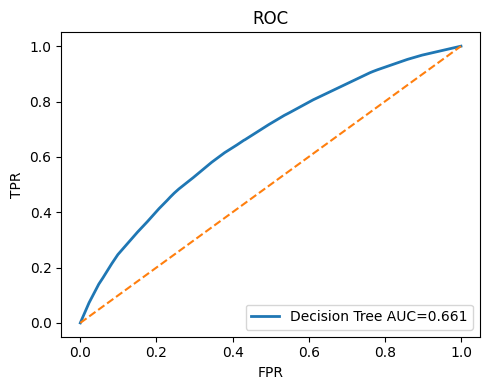

Decision Tree — AUC: 0.661 | PR-AUC: 0.296 | Lift@10%: 2.01x
Confusion matrix (0.5):
 [[99577 60826]
 [14092 22523]]

Classification report:
               precision    recall  f1-score   support

           0      0.876     0.621     0.727    160403
           1      0.270     0.615     0.375     36615

    accuracy                          0.620    197018
   macro avg      0.573     0.618     0.551    197018
weighted avg      0.763     0.620     0.661    197018



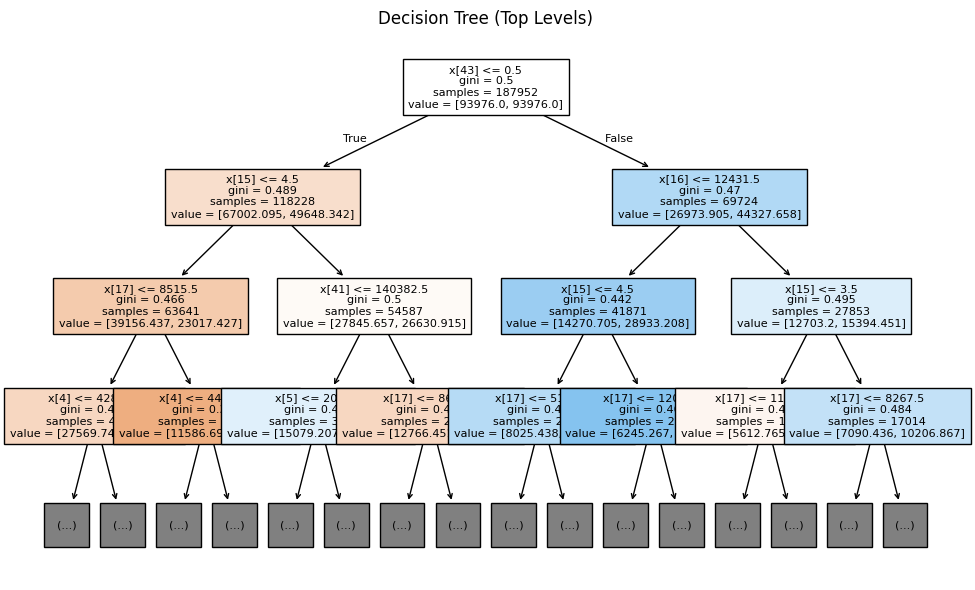

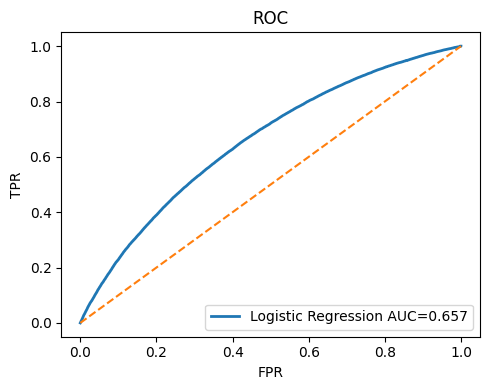

Logistic Regression — AUC: 0.657 | PR-AUC: 0.291 | Lift@10%: 1.89x
Confusion matrix (0.5):
 [[91908 68495]
 [12574 24041]]

Classification report:
               precision    recall  f1-score   support

           0      0.880     0.573     0.694    160403
           1      0.260     0.657     0.372     36615

    accuracy                          0.589    197018
   macro avg      0.570     0.615     0.533    197018
weighted avg      0.764     0.589     0.634    197018

Baseline (Grade+Rate) AUC: 0.686
AUC — Tree: 0.661 | Logit: 0.657


In [39]:
pre_app = build_pipeline(APP_FEATURES, dtype_ref_df=balanced_train)

def evaluate_clf(clf, X_test, y_test, label=""):
    proba = clf.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    fpr, tpr, _ = roc_curve(y_test, proba)
    # ROC
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, lw=2, label=f'{label} AUC={auc:.3f}')
    plt.plot([0,1],[0,1],'--'); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC'); plt.legend(loc='lower right')
    plt.tight_layout(); 
    plt.savefig(f'figs/roc_{label.replace(" ","_").lower()}.png', dpi=200, bbox_inches='tight')
    plt.show()
    # Lift@10%
    k = max(1, int(0.10 * len(proba)))
    idx = np.argsort(proba)[::-1][:k]
    lift_at_10 = y_test.iloc[idx].mean() / y_test.mean()
    # Confusion @0.5
    pred = (proba>=0.5).astype(int)
    cm = confusion_matrix(y_test, pred)
    print(f"{label} — AUC: {auc:.3f} | PR-AUC: {pr_auc:.3f} | Lift@10%: {lift_at_10:.2f}x")
    print("Confusion matrix (0.5):\n", cm)
    print("\nClassification report:\n", classification_report(y_test, pred, digits=3))
    return auc, pr_auc, lift_at_10

# Decision Tree
tree = DecisionTreeClassifier(max_depth=5, min_samples_leaf=200, class_weight='balanced', random_state=42)
tree_clf = Pipeline([('pre', pre_app), ('tree', tree)])
tree_clf.fit(balanced_train[APP_FEATURES], balanced_train['y_default'])
auc_tree, pr_tree, lift_tree = evaluate_clf(tree_clf, test_df[APP_FEATURES], test_df['y_default'], label='Decision Tree')

# Tree plot (top levels)
try:
    plt.figure(figsize=(10,6))
    plot_tree(tree_clf.named_steps['tree'], filled=True, max_depth=3, fontsize=8)
    plt.title('Decision Tree (Top Levels)'); 
    plt.tight_layout(); 
    plt.savefig('figs/tree_top_levels.png', dpi=200, bbox_inches='tight'); plt.show()
except Exception as e:
    print("Tree plot skipped:", e)

# Logistic Regression
logit = LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear')
logit_clf = Pipeline([('pre', pre_app), ('logit', logit)])
logit_clf.fit(balanced_train[APP_FEATURES], balanced_train['y_default'])
auc_logit, pr_logit, lift_logit = evaluate_clf(logit_clf, test_df[APP_FEATURES], test_df['y_default'], label='Logistic Regression')

print(f"Baseline (Grade+Rate) AUC: {baseline_auc:.3f}")
print(f"AUC — Tree: {auc_tree:.3f} | Logit: {auc_logit:.3f}")

,feature,coef
0,dti,0.015
1,acc_open_past_24mths,0.009
2,mo_sin_rcnt_tl,-0.009
3,mo_sin_rcnt_rev_tl_op,-0.008
4,num_tl_op_past_12m,0.005
5,num_op_rev_tl,0.004
6,num_actv_rev_tl,0.004
7,percent_bc_gt_75,0.004
8,num_rev_tl_bal_gt_0,0.004
9,open_acc,0.003


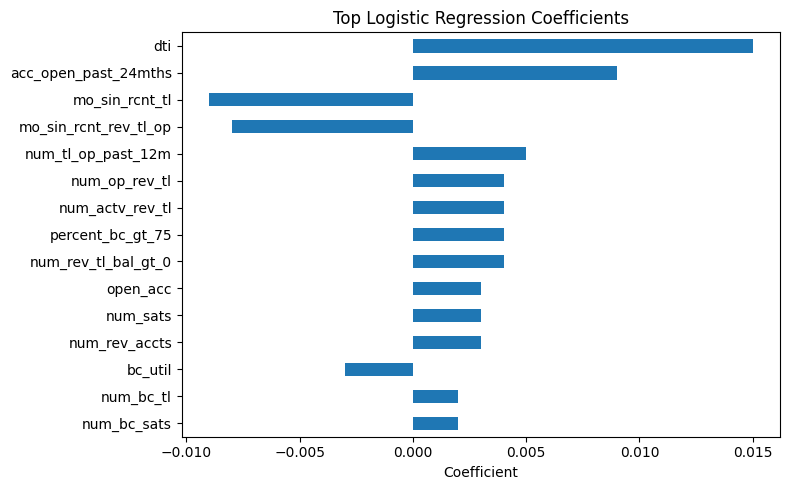

In [40]:
# Extract post-OHE feature names
def get_feature_names_from_pipeline(pipeline, features, dtype_ref_df):
    num_cols, cat_cols = split_num_cat(features, dtype_ref_df)
    names = list(num_cols)
    if cat_cols:
        ohe = pipeline.named_steps['pre'].named_transformers_['cat'].named_steps['onehot']
        names.extend(list(ohe.get_feature_names_out(cat_cols)))
    return names

feat_names = get_feature_names_from_pipeline(logit_clf, APP_FEATURES, dtype_ref_df=balanced_train)
coefs = pd.Series(logit_clf.named_steps['logit'].coef_.ravel(), index=feat_names).sort_values(key=lambda x: np.abs(x), ascending=False)
topk = coefs.head(15).round(3)

# Export table for slides
coef_df = topk.to_frame('coef').reset_index().rename(columns={'index':'feature'})
coef_df.to_csv('table_logit_top_coefs.csv', index=False)
display(coef_df)

# Plot
plt.figure(figsize=(8,5))
topk.iloc[::-1].plot(kind='barh')
plt.xlabel('Coefficient'); plt.title('Top Logistic Regression Coefficients')
plt.tight_layout(); 
plt.savefig('figs/logit_top_coefs.png', dpi=200, bbox_inches='tight'); plt.show()

Best alpha: 10
Ridge Regression — R^2: 0.075  RMSE: 0.2244


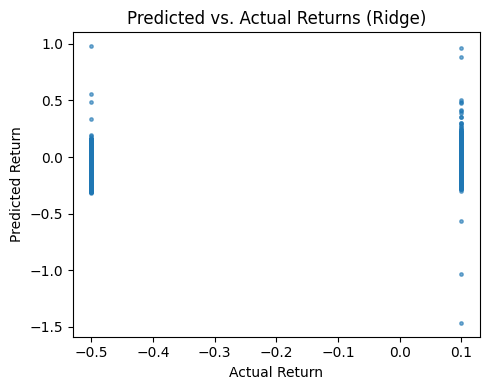

In [41]:
# Detect/use return column
if 'return_intermediate' in df.columns:
    ret_col = 'return_intermediate'
elif 'return_pessimistic' in df.columns:
    ret_col = 'return_pessimistic'
elif 'return_optimistic' in df.columns:
    ret_col = 'return_optimistic'
else:
    ret_col = 'return_proxy'
    if ret_col not in df.columns:
        df[ret_col] = np.where(df['y_default']==1, -0.5, 0.10)

# Ensure ret on splits
if ret_col not in train_df.columns: train_df = train_df.join(df[[ret_col]], how='left')
if ret_col not in test_df.columns:  test_df  = test_df.join(df[[ret_col]],  how='left')

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

pre_ret = build_pipeline(APP_FEATURES, dtype_ref_df=train_df)
ridge = Ridge()
pipe = Pipeline([('pre', pre_ret), ('ridge', ridge)])
grid = GridSearchCV(pipe, {'ridge__alpha':[0.1,0.3,1,3,10]}, scoring='neg_mean_squared_error', cv=5)
grid.fit(train_df[APP_FEATURES], train_df[ret_col])
best = grid.best_estimator_
pred = best.predict(test_df[APP_FEATURES])

r2 = r2_score(test_df[ret_col], pred)
rmse = math.sqrt(mean_squared_error(test_df[ret_col], pred))
print("Best alpha:", grid.best_params_['ridge__alpha'])
print(f"Ridge Regression — R^2: {r2:.3f}  RMSE: {rmse:.4f}")

plt.figure(figsize=(5,4))
plt.scatter(test_df[ret_col], pred, s=6, alpha=0.6)
plt.xlabel('Actual Return'); plt.ylabel('Predicted Return')
plt.title('Predicted vs. Actual Returns (Ridge)')
plt.tight_layout(); 
plt.savefig('figs/ridge_pred_vs_actual.png', dpi=200, bbox_inches='tight'); plt.show()

,strategy,avg_return
0,Low Default Prob,0.076
1,High Predicted Return,0.070
2,Random,0.022


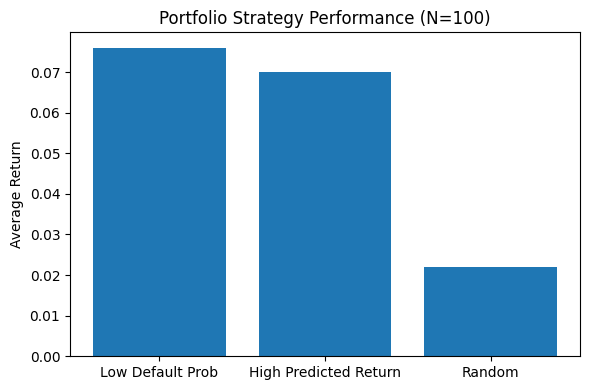

strategy,High Predicted Return,Low Default Prob,Random
N,,,
20,0.0100,0.070,0.0400
100,0.0700,0.076,0.0220
1000,0.0766,0.055,-0.0014


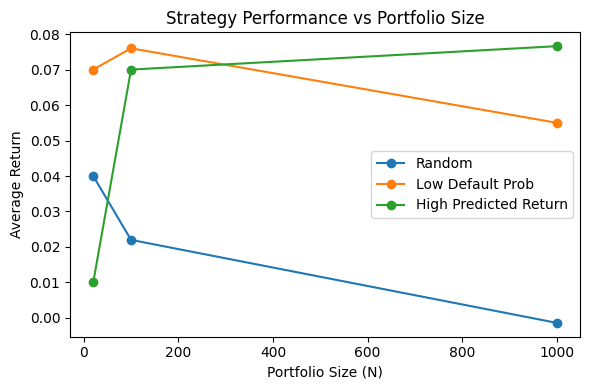

In [42]:
N_PICK = 100
pool = test_df.dropna(subset=APP_FEATURES).copy()

# PD from winner
winner = logit_clf if (auc_logit >= auc_tree) else tree_clf
pool['pd_hat'] = winner.predict_proba(pool[APP_FEATURES])[:,1]

# Predicted return from tuned Ridge
pool['ret_hat'] = best.predict(pool[APP_FEATURES])

def pick(df, col, k, ascending):
    return df.sort_values(col, ascending=ascending).head(k)

port_random = pool.sample(n=min(N_PICK, len(pool)), random_state=42)
port_lowpd  = pick(pool, 'pd_hat',  N_PICK, ascending=True)
port_highr  = pick(pool, 'ret_hat', N_PICK, ascending=False)

res = pd.DataFrame({
    'strategy': ['Random','Low Default Prob','High Predicted Return'],
    'avg_return': [port_random[ret_col].mean(), port_lowpd[ret_col].mean(), port_highr[ret_col].mean()]
}).sort_values('avg_return', ascending=False).reset_index(drop=True)
display(res)
res.to_csv('table_strategy_comparison.csv', index=False)

plt.figure(figsize=(6,4))
plt.bar(res['strategy'], res['avg_return'])
plt.ylabel('Average Return'); plt.title(f'Portfolio Strategy Performance (N={N_PICK})')
plt.tight_layout(); 
plt.savefig('figs/strategy_bar.png', dpi=200, bbox_inches='tight'); plt.show()

# Sensitivity
sizes = [20, 100, 1000]
rows = []
for k in sizes:
    rows += [
        ['Random', k, pool.sample(n=min(k, len(pool)), random_state=42)[ret_col].mean()],
        ['Low Default Prob', k, pick(pool, 'pd_hat', k, True)[ret_col].mean()],
        ['High Predicted Return', k, pick(pool, 'ret_hat', k, False)[ret_col].mean()],
    ]
sens = pd.DataFrame(rows, columns=['strategy','N','avg_return'])
pivot = sens.pivot(index='N', columns='strategy', values='avg_return').round(4)
display(pivot)
pivot.to_csv('table_strategy_sensitivity.csv')

plt.figure(figsize=(6,4))
for s in sens['strategy'].unique():
    sub = sens[sens['strategy']==s]
    plt.plot(sub['N'], sub['avg_return'], marker='o', label=s)
plt.xlabel('Portfolio Size (N)'); plt.ylabel('Average Return')
plt.title('Strategy Performance vs Portfolio Size')
plt.legend(); plt.tight_layout(); 
plt.savefig('figs/strategy_sensitivity.png', dpi=200, bbox_inches='tight'); plt.show()

In [43]:
for name in ["pool", "ret_col"]:
    assert name in globals(), f"Missing variable: {name}"
for name in ["res", "sens"]:
    assert name in globals(), f"Run the strategy cell first to create: {name}"

# Print clean numeric tables
print("\nStrategy Comparison (mean returns):")
print(res.to_string(index=False))

print("\nStrategy Size Sensitivity (pivot):")
pivot = sens.pivot(index='N', columns='strategy', values='avg_return').round(4)
print(pivot.to_string())

expected = [
    "table_strategy_comparison.csv",
    "table_strategy_sensitivity.csv",
    "fig_strategy_bar.png",
    "fig_strategy_sensitivity.png",
]
print("\nExport check:")
for f in expected:
    print(f, "->", "FOUND" if os.path.exists(f) else "missing")


Strategy Comparison (mean returns):
             strategy  avg_return
     Low Default Prob       0.076
High Predicted Return       0.070
               Random       0.022

Strategy Size Sensitivity (pivot):
strategy  High Predicted Return  Low Default Prob  Random
N                                                        
20                       0.0100             0.070  0.0400
100                      0.0700             0.076  0.0220
1000                     0.0766             0.055 -0.0014

Export check:
table_strategy_comparison.csv -> FOUND
table_strategy_sensitivity.csv -> FOUND
fig_strategy_bar.png -> missing
fig_strategy_sensitivity.png -> missing
